In [ ]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import urllib3
import time
from joblib import Parallel, delayed
import warnings

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
sns.set_theme(style="whitegrid")

BASE_URL = "http://localhost:5222" 
BATTLE_ENDPOINT = f"{BASE_URL}/BattleCalculator/calculate-specific-units-team"
STATS_ENDPOINT = f"{BASE_URL}/unit-stats"

UNIT_TYPES = {
    0: "Light",
    1: "Heavy",
    2: "Fast",
    3: "ShortRange",
    4: "LongRange"
}

In [30]:
def get_current_stats():
    response = requests.get(STATS_ENDPOINT, verify=False)
    return response.json()

def update_stats(new_stats):
    requests.post(STATS_ENDPOINT, json=new_stats, verify=False)

def run_simulation(type_a, type_b, iterations=500):
    payload = {
        "battle-id": "jupyter_sim_session",
        "unit-type-A": type_a,
        "unit-type-B": type_b
    }
    
    wins_a = 0
    name_a = UNIT_TYPES[type_a]
    

    with requests.Session() as session:
        session.verify = False
        
        for _ in range(iterations):
            try:
                resp = session.post(BATTLE_ENDPOINT, json=payload)
                
                if resp.status_code == 200:
                    if name_a in resp.json().get("winner", ""):
                        wins_a += 1
            except Exception as e:
                continue
            
    return (wins_a / iterations) * 100

In [31]:
def _run_single_matchup(id_a, id_b, name_a, name_b, iterations):
    if id_a == id_b:
        return name_a, name_b, 50.0
    
    wr = run_simulation(id_a, id_b, iterations)
    return name_a, name_b, wr

def generate_balance_matrix(iterations=200):
    ids = list(UNIT_TYPES.keys())
    names = [UNIT_TYPES[i] for i in ids]
    
    results = Parallel(n_jobs=-1)(
        delayed(_run_single_matchup)(id_a, id_b, UNIT_TYPES[id_a], UNIT_TYPES[id_b], iterations)
        for id_a in ids 
        for id_b in ids
    )
    
    matrix = pd.DataFrame(index=names, columns=names)
    for name_a, name_b, wr in results:
        matrix.loc[name_a, name_b] = wr
        
    return matrix.astype(float)

def plot_balance_history(attack_history, wr_history, target_wr=50.0, tolerance=4.0):
    epochs = range(1, len(next(iter(attack_history.values()))) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for unit, stats in attack_history.items():
        ax1.plot(epochs, stats, marker='o', label=unit, linewidth=2)
    
    ax1.set_title('Attack', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Attack Value', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    ax1.set_xticks(epochs)

    for unit, wrs in wr_history.items():
        ax2.plot(epochs, wrs, marker='s', label=unit, linewidth=2)
    
    ax2.axhline(target_wr, color='red', linestyle='-', alpha=0.5, label='Ideal (50%)')
    ax2.fill_between(epochs, target_wr - tolerance, target_wr + tolerance, 
                     color='red', alpha=0.1, label='Balance Zone')
    
    ax2.set_title('WR', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Avg Win Rate (%)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    ax2.set_xticks(epochs)

    plt.tight_layout()
    plt.show()

def auto_balance_units(target_wr=50.0, tolerance=5.0, max_epochs=10, sim_iterations=100):
    current_stats = get_current_stats()
    
    unit_names = [UNIT_TYPES[i] for i in UNIT_TYPES.keys()]
    attack_history = {name: [] for name in unit_names}
    wr_history = {name: [] for name in unit_names}
    
    for epoch in range(max_epochs):
        print(f"\n[{epoch + 1}/{max_epochs}] Simulating battles...")
        
        df_results = generate_balance_matrix(iterations=sim_iterations)
        is_balanced = True

        for unit_name in df_results.index:
            row = df_results.loc[unit_name]
            avg_wr = row[row.index != unit_name].mean()
            current_attack = current_stats[unit_name]["attack"]
            
            attack_history[unit_name].append(current_attack)
            wr_history[unit_name].append(avg_wr)
            
            print(f"[{unit_name}] WR: {avg_wr:.1f}% | Attack: {current_attack}", end=" -> ")
            
            if avg_wr > (target_wr + tolerance):
                print("Nerf (-1 attack)")
                current_stats[unit_name]["attack"] = max(1, current_attack - 1)
                is_balanced = False
            elif avg_wr < (target_wr - tolerance):
                print("Buff (+1 attack)")
                current_stats[unit_name]["attack"] += 1
                is_balanced = False
            else:
                print("Balanced")
                
        if is_balanced:
            print("\nSUCCESS: All units are balanced!")
            break
            
        if epoch < max_epochs - 1:
            update_stats(current_stats)
            time.sleep(2) 

    return current_stats, attack_history, wr_history


[1/3] Simulating battles...
[Light] WR: 5.0% | Attack: 31 -> Buff (+1 attack)
[Heavy] WR: 20.8% | Attack: 36 -> Buff (+1 attack)
[Fast] WR: 100.0% | Attack: 1 -> Nerf (-1 attack)
[ShortRange] WR: 50.0% | Attack: 15 -> Balanced
[LongRange] WR: 75.0% | Attack: 2 -> Nerf (-1 attack)

[2/3] Simulating battles...
[Light] WR: 3.6% | Attack: 32 -> Buff (+1 attack)
[Heavy] WR: 20.7% | Attack: 37 -> Buff (+1 attack)
[Fast] WR: 100.0% | Attack: 1 -> Nerf (-1 attack)
[ShortRange] WR: 50.0% | Attack: 15 -> Balanced
[LongRange] WR: 75.0% | Attack: 1 -> Nerf (-1 attack)

[3/3] Simulating battles...
[Light] WR: 3.7% | Attack: 33 -> Buff (+1 attack)
[Heavy] WR: 20.5% | Attack: 38 -> Buff (+1 attack)
[Fast] WR: 100.0% | Attack: 1 -> Nerf (-1 attack)
[ShortRange] WR: 50.0% | Attack: 15 -> Balanced
[LongRange] WR: 75.0% | Attack: 1 -> Nerf (-1 attack)


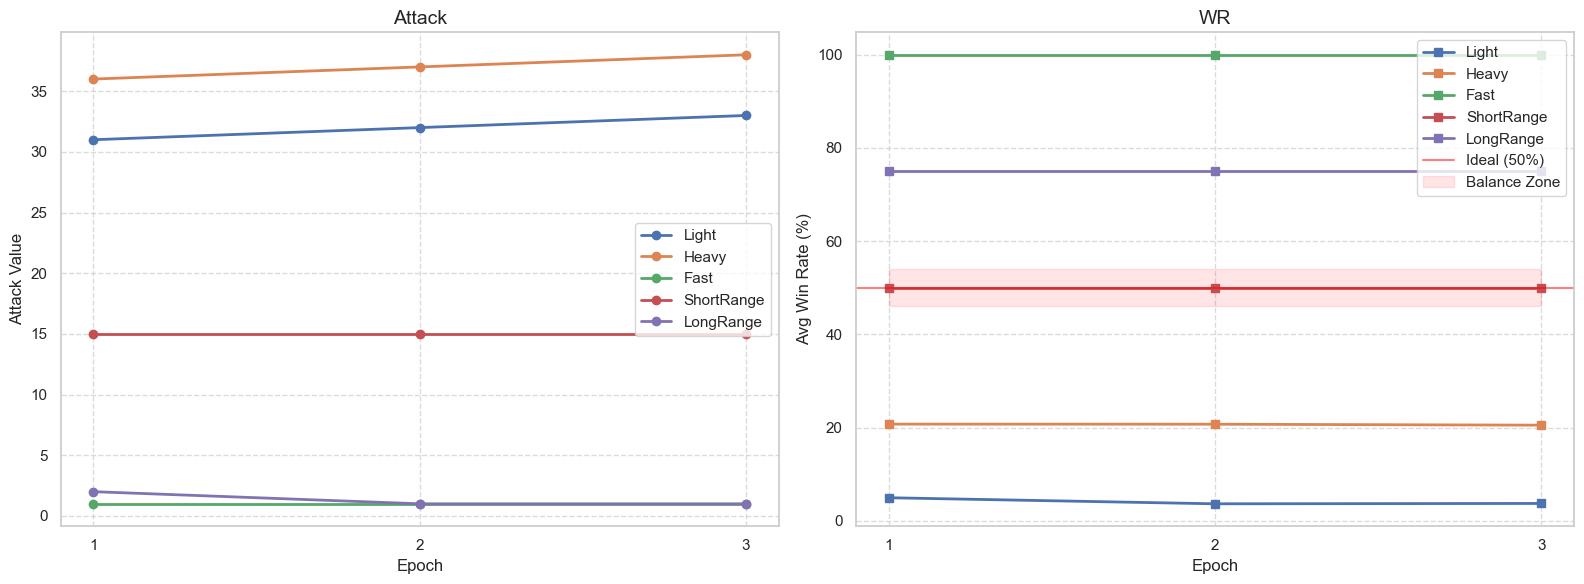

Light: Атака = 34
Heavy: Атака = 39
Fast: Атака = 1
ShortRange: Атака = 15
LongRange: Атака = 1


In [ ]:
final_stats, history_attack, history_wr = auto_balance_units(
    target_wr=50.0, 
    tolerance=4.0,       
    max_epochs=10,       
    sim_iterations=10000
)

plot_balance_history(history_attack, history_wr, target_wr=50.0, tolerance=4.0)

for unit, data in final_stats.items():
    print(f"{unit}: Attack = {data['attack']}")